In [40]:
import pandas as pd
import soccerdata as sd
from soccerdata import FBref


#Fetching historical data from the past five seasons
past_seasons = ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
all_stats = []

for season in past_seasons:
    print("Fetching season:", season)

    #Create a scraper class for a specific season with FBref
    fbref = sd.FBref('ENG-Premier League', season)

    player_season_stats = fbref.read_player_season_stats(stat_type="standard").reset_index()
    df_misc = fbref.read_player_season_stats(stat_type="misc").reset_index()
    df_kp = fbref.read_player_season_stats(stat_type="keeper").reset_index()
    df_shoot = fbref.read_player_season_stats(stat_type="shooting").reset_index()



    #Function for fixing multicolumn index issue 
    def clean_col(df):
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = ['_'.join(col).strip('_') if col[0] else col[1] for col in df.columns]
        return df

    #Calling the function to fix the multicolumn issue
    player_season_stats = clean_col(player_season_stats)
    df_misc = clean_col(df_misc)
    df_kp = clean_col(df_kp)
    df_shoot = clean_col(df_shoot)

    #Filter specific stats to avoid overlapping data
    shoot_cols = ['player', 'team', 'Standard_Gls', 'Standard_Sh', 'Standard_SoT',
                'Standard_SoT%', 'Standard_Sh/90', 'Standard_SoT/90', 'Standard_G/Sh',
                'Standard_G/SoT']
    kp_cols = ['player', 'team', 'Performance_GA', 'Performance_GA90', 'Performance_SoTA',
               'Performance_Saves', 'Performance_Save%', 'Performance_W', 'Performance_D',
               'Performance_L', 'Performance_CS', 'Performance_CS%', 'Penalty Kicks_PKatt',
                'Penalty Kicks_PKA', 'Penalty Kicks_PKsv', 'Penalty Kicks_PKm', 'Penalty Kicks_Save%']
    misc_cols = ['player', 'team', 'Performance_2CrdY',
                    'Performance_Fls', 'Performance_Fld', 'Performance_Off', 'Performance_Crs',
                    'Performance_Int', 'Performance_TklW','Performance_OG']

    filter_shoot = df_shoot[[c for c in shoot_cols if c in df_shoot.columns]]
    filter_misc = df_misc[[c for c in misc_cols if c in df_misc.columns]]
    filter_kp = df_kp[[c for c in kp_cols if c in df_kp.columns]]

    #mergring the df
    merged_df = pd.merge(player_season_stats, filter_shoot, on=['player', 'team'], how='left')
    merged_df = pd.merge(merged_df, filter_misc, on=['player', 'team'], how='left')
    merged_df = pd.merge(merged_df, filter_kp, on=['player', 'team'], how='left')

    #Tracking seasons
    merged_df['season'] = season
    all_stats.append(merged_df)
    

#Combine all past season stats
all_years_df = pd.concat(all_stats, ignore_index = True)

#Checking number of rows of player data
print(f"{len(all_years_df)} historical player season stats loaded")

#Display and inspect the first few rows of player stats
all_years_df.head()

all_years_df.to_csv('all_players_stats.csv', index = False)



    




Fetching season: 2021-22


[09/09/26 20:57:57] INFO     Saving cached data to C:\Users\user\soccerdata\data\FBref               ]8;id=3688544;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=3688545;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

Fetching season: 2022-23


[09/09/26 20:58:03] INFO     Saving cached data to C:\Users\user\soccerdata\data\FBref               ]8;id=3688550;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=3688551;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

Fetching season: 2023-24


...

Fetching season: 2024-25


[09/09/26 20:58:12] INFO     Saving cached data to C:\Users\user\soccerdata\data\FBref               ]8;id=3688562;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=3688563;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

Fetching season: 2025-26


[09/09/26 20:58:21] INFO     Saving cached data to C:\Users\user\soccerdata\data\FBref               ]8;id=3688568;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=3688569;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

2820 historical player season stats loaded


In [ ]:
#Inspecting my new dataframe
all_years_df.head()

,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Performance_W,Performance_D,Performance_L,Performance_CS,Performance_CS%,Penalty Kicks_PKatt,Penalty Kicks_PKA,Penalty Kicks_PKsv,Penalty Kicks_PKm,Penalty Kicks_Save%
0,ENG-Premier League,2021-22,Arsenal,Aaron Ramsdale,ENG,GK,23,1998,34,34,...,21,3,10,12,35.3,6,5,0,1,0.0
1,ENG-Premier League,2021-22,Arsenal,Ainsley Maitland-Niles,ENG,MF,23,1997,8,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,ENG-Premier League,2021-22,Arsenal,Albert Sambi Lokonga,BEL,MF,21,1999,19,12,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,ENG-Premier League,2021-22,Arsenal,Alexandre Lacazette,FRA,"FW,MF",30,1991,30,20,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,ENG-Premier League,2021-22,Arsenal,Ben White,ENG,DF,23,1997,32,32,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [41]:
#Merging player market value with player stats
from thefuzz import process

valuations = pd.read_csv("player_valuations.csv")
players = pd.read_csv("players.csv")

val_merged = pd.merge(valuations, players[['player_id', 'name', 'current_club_domestic_competition_id']], on = 'player_id')

#Keep only epl players
epl_vals = val_merged[val_merged['current_club_domestic_competition_id'] == 'GB1'].copy()



#Changing the date into the format of Season
epl_vals['Year'] = epl_vals['date'].str[:4]

def map_to_season_format(year):
    year_int = int(year)
    return f"{year_int-1}-{str(year)[2:]}"

epl_vals['season'] = epl_vals['Year'].apply(map_to_season_format)
print("Season format changed successfully")


#Finding the highest market value for a player in the same season
values_df = epl_vals.groupby(['name', 'season'])['market_value_in_eur'].max().reset_index()
values_df.columns = ['Player', 'season', 'Market_value_eur']
print(f"{len(values_df)} market value data loaded")
values_df.to_csv('cleaned_market_value.csv', index = False)

#Merge the two new csv using fuzzymatching
stats_df = all_years_df
final_merged_rows = []

#Extract seasons we are using to train this model
unique_seasons = stats_df['season'].unique()
print(unique_seasons)
for s in unique_seasons:
    s_stats = stats_df[stats_df['season'] == s]
    #string converstion
    s_vals = values_df[values_df['season'] == str(s)]

    #Extract player name using fuzzy match
    val_name_list = s_vals['Player'].tolist()

    for _, row in s_stats.iterrows():
        stats_name = row['player']

        #prevent program from crashing due to names in incorrect format or missing data
        if not isinstance(stats_name, str):
            continue

        #Calc close text similarities fixing potential name format issues between two dataframes
        best_match, score,  = process.extractOne(stats_name, val_name_list)

        if score >= 85:
            #fix: .values[0] needed otherwise csv shows the type as well
            matched_val = s_vals[s_vals['Player'] == best_match]['Market_value_eur'].values[0]

            row_dict = row.to_dict()
            row_dict['Market_value_eur'] = matched_val
            final_merged_rows.append(row_dict)

#Saving the file
if final_merged_rows:
    master_raw_df = pd.DataFrame(final_merged_rows)
    master_raw_df.to_csv("master_data.csv", index = False)
    print("master data cleaned successfully")
    print(master_raw_df.head())
    print(f"{len(master_raw_df)} rows of data")
else:
    print("Error occured, file not saved")









Season format changed successfully
16019 market value data loaded
<StringArray>
['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Length: 5, dtype: str
master data cleaned successfully
               league   season     team                player nation    pos  \
0  ENG-Premier League  2021-22  Arsenal        Aaron Ramsdale    ENG     GK   
1  ENG-Premier League  2021-22  Arsenal  Albert Sambi Lokonga    BEL     MF   
2  ENG-Premier League  2021-22  Arsenal   Alexandre Lacazette    FRA  FW,MF   
3  ENG-Premier League  2021-22  Arsenal             Ben White    ENG     DF   
4  ENG-Premier League  2021-22  Arsenal            Bernd Leno    GER     GK   

   age  born  Playing Time_MP  Playing Time_Starts  ...  Performance_D  \
0   23  1998               34                   34  ...            3.0   
1   21  1999               19                   12  ...            NaN   
2   30  1991               30                   20  ...            NaN   
3   23  1997               32         

In [42]:
#Understanding the data
import numpy as np
df_to_check = master_raw_df 

for column in df_to_check.columns:
    unique_vals = df_to_check[column].fillna('0').unique()
    nr_vals = len(unique_vals)
    if nr_vals <= 12:
        print('The number of values for feature {} :{} -- {}'.format(column, nr_vals, unique_vals))
    else:
        print('The number of values for feature {} :{}'.format(column, nr_vals))

The number of values for feature league :1 -- <StringArray>
['ENG-Premier League']
Length: 1, dtype: str
The number of values for feature season :5 -- <StringArray>
['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Length: 5, dtype: str
The number of values for feature team :27
The number of values for feature player :835
The number of values for feature nation :79
The number of values for feature pos :9 -- <StringArray>
['GK', 'MF', 'FW,MF', 'DF', 'MF,FW', 'FW', 'DF,FW', 'DF,MF', 'MF,DF']
Length: 9, dtype: str
The number of values for feature age :25
The number of values for feature born :27
The number of values for feature Playing Time_MP :38
The number of values for feature Playing Time_Starts :39
The number of values for feature Playing Time_Min :1414
The number of values for feature Playing Time_90s :377
The number of values for feature Performance_Gls :26
The number of values for feature Performance_Ast :17
The number of values for feature Performance_G+A :37
The number of 

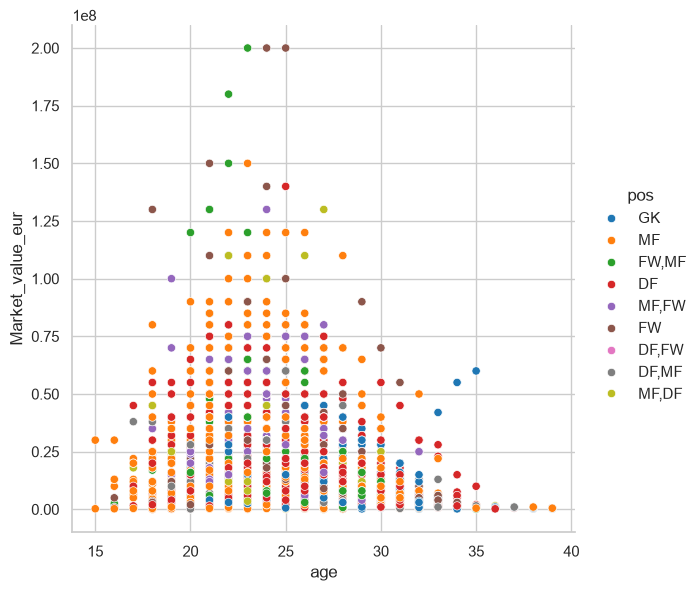

per 90 stats generated


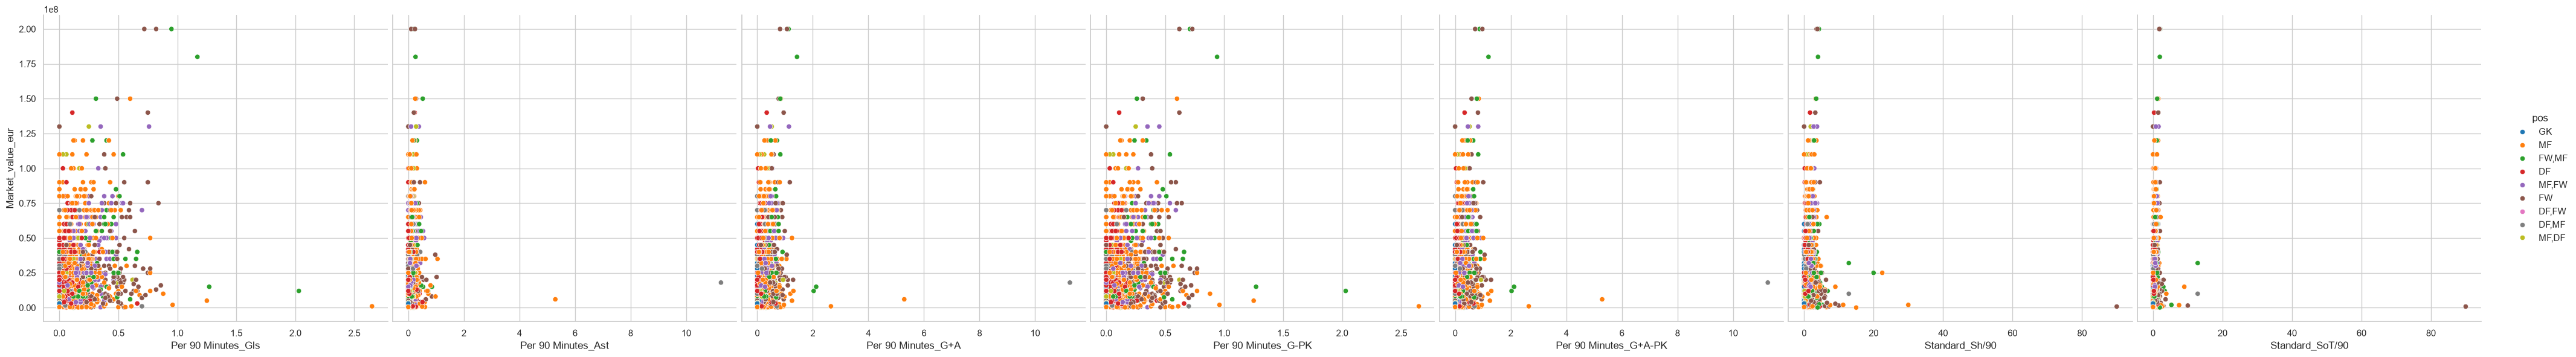

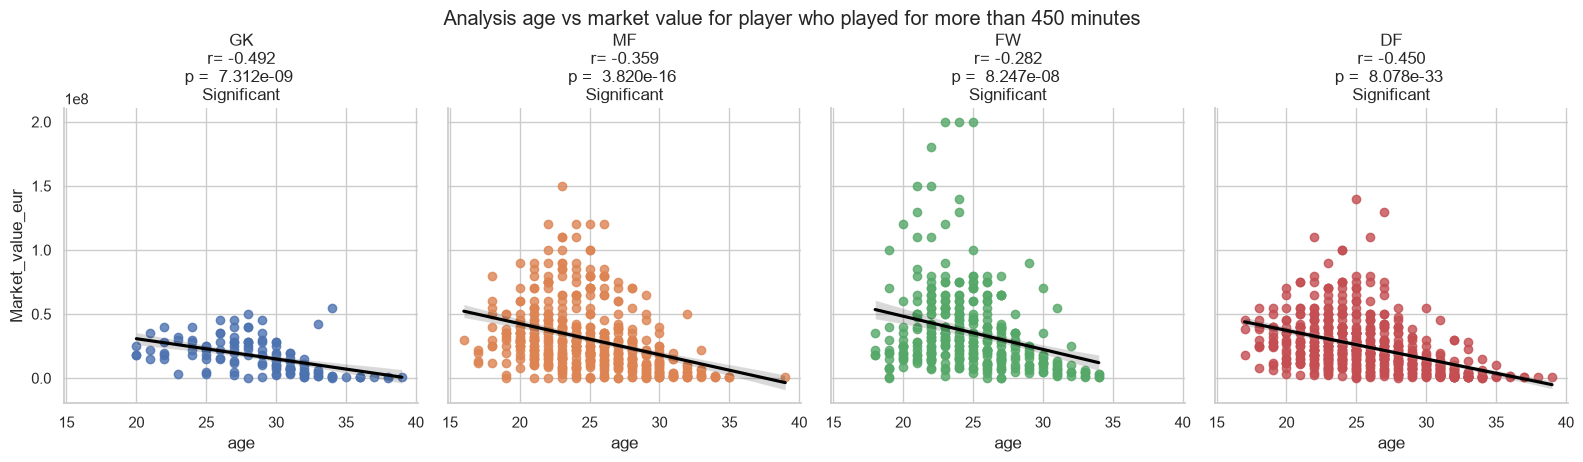

[09/09/26 20:58:43] WARNING  C:\Users\user\AppData\Local\Temp\ipykernel_30020\813089137.py:65:  ]8;id=3688574;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=3688575;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             ConstantInputWarning: An input array is constant; the correlation                     
                             coefficient is not defined.                                                           
                               r_val, p_val = stats.pearsonr(clean_slice,                                          
                             clean_slice['Market_value_eur'])                                                      
                                                                                                                   

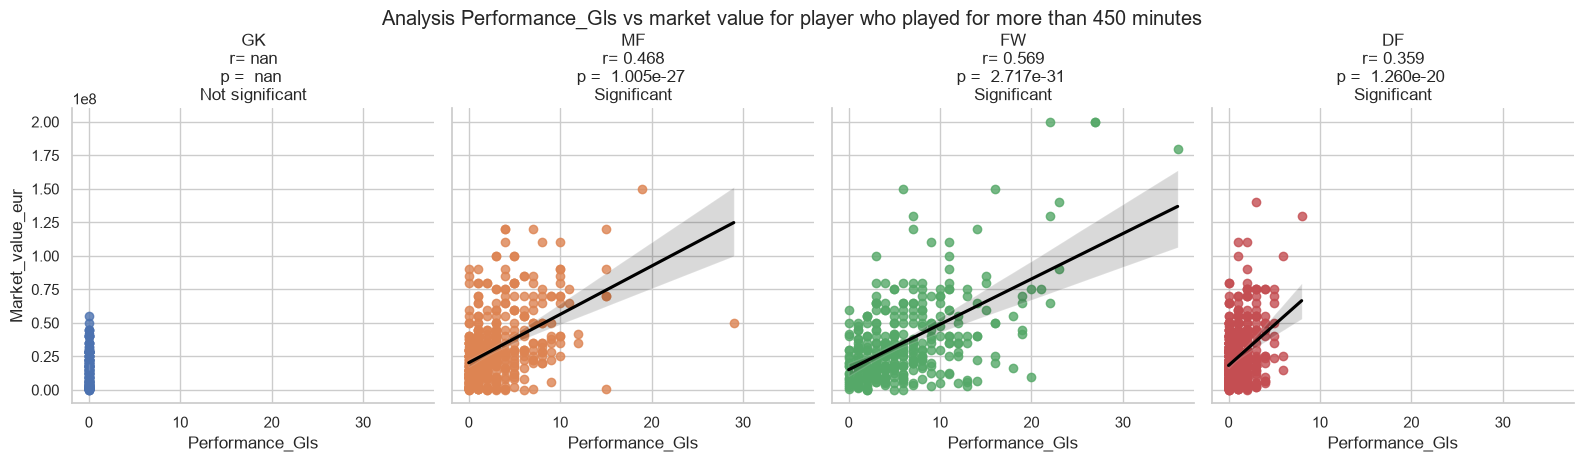

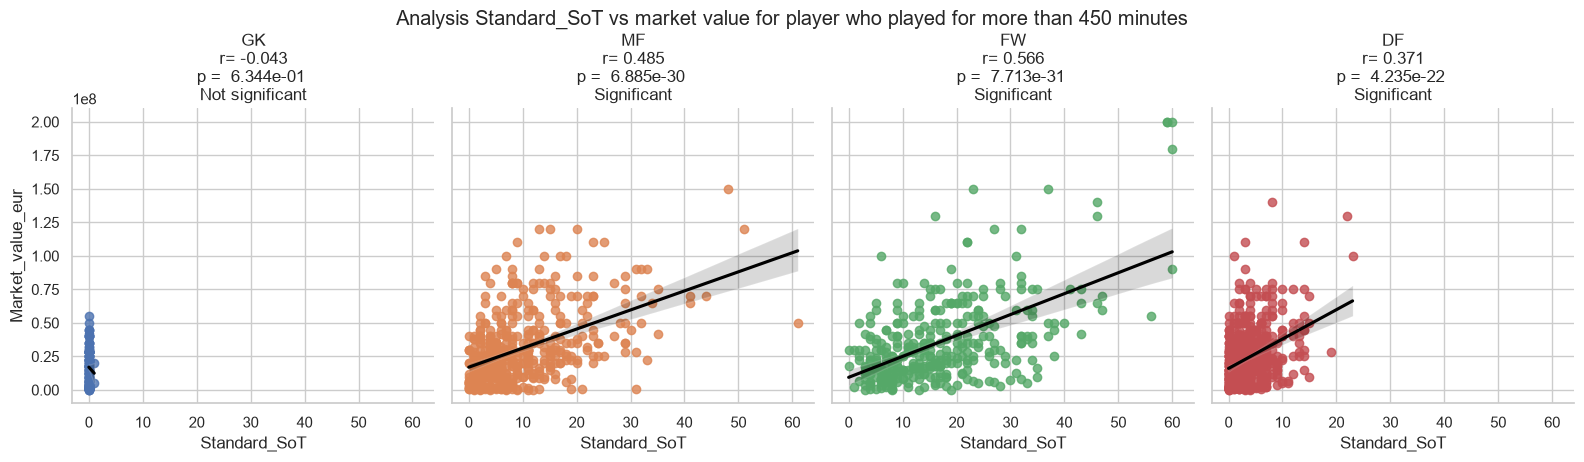

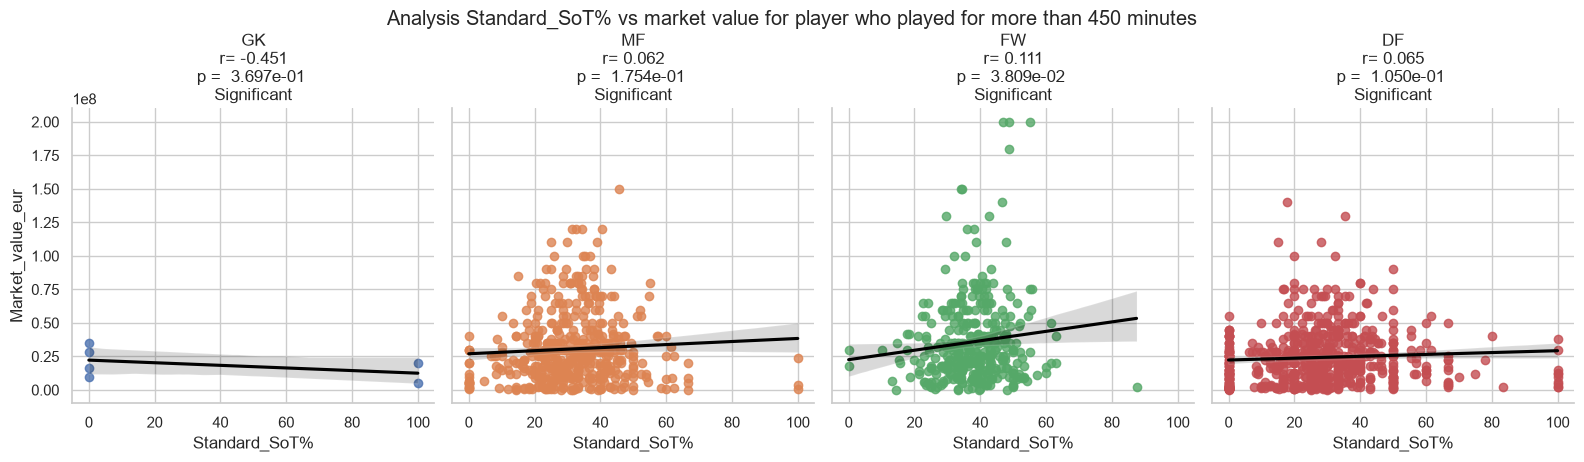

[09/09/26 20:58:45] WARNING  C:\Users\user\AppData\Local\Temp\ipykernel_30020\813089137.py:65:  ]8;id=3688580;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=3688581;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             ConstantInputWarning: An input array is constant; the correlation                     
                             coefficient is not defined.                                                           
                               r_val, p_val = stats.pearsonr(clean_slice,                                          
                             clean_slice['Market_value_eur'])                                                      
                                                                                                                   

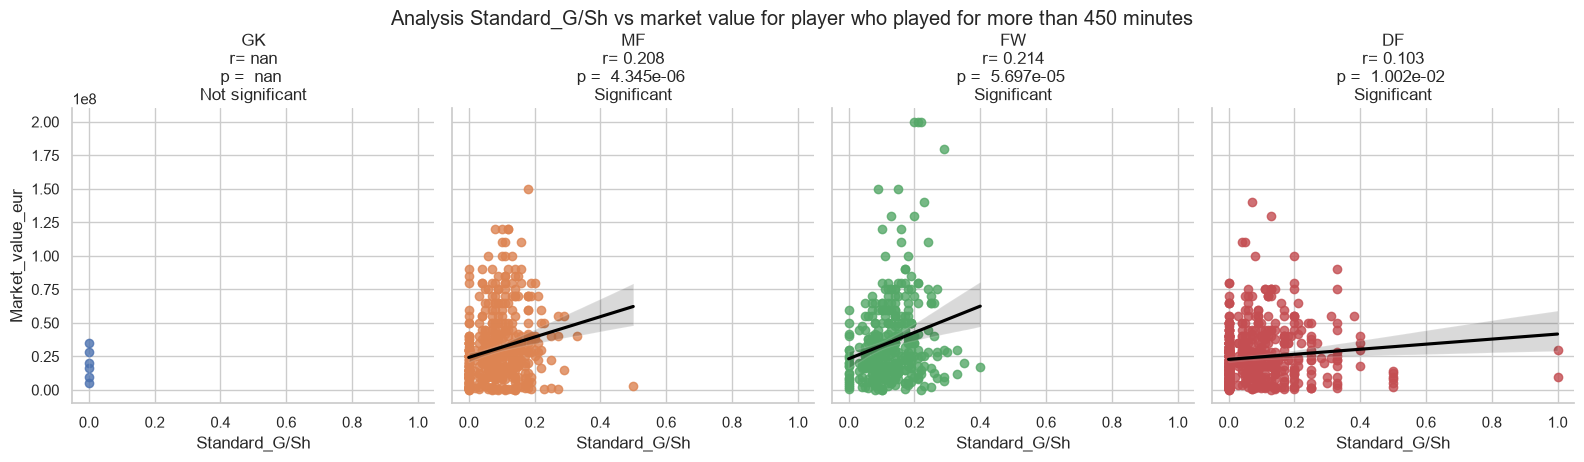

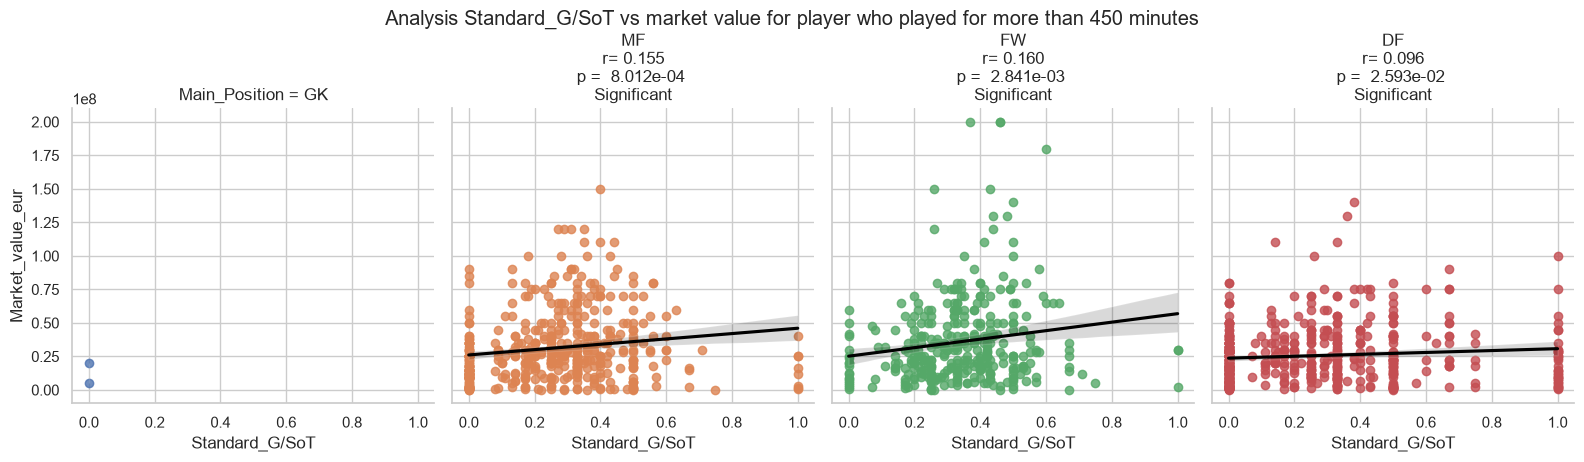

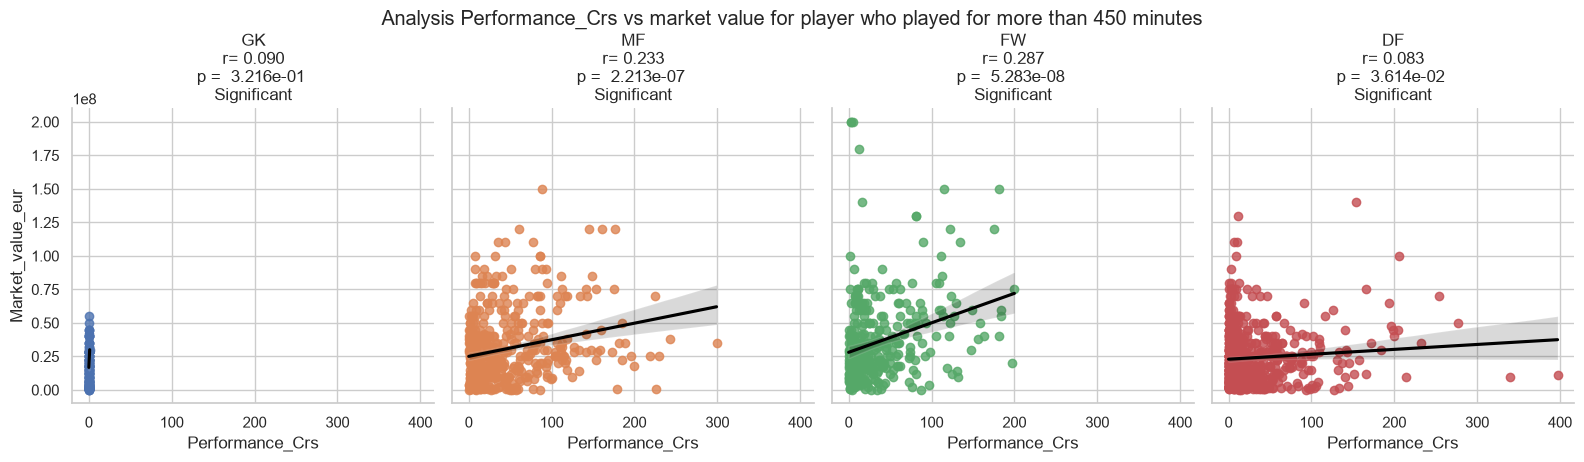

[09/09/26 20:58:55] WARNING  C:\Users\user\AppData\Local\Temp\ipykernel_30020\813089137.py:65:  ]8;id=3688586;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=3688587;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             ConstantInputWarning: An input array is constant; the correlation                     
                             coefficient is not defined.                                                           
                               r_val, p_val = stats.pearsonr(clean_slice,                                          
                             clean_slice['Market_value_eur'])                                                      
                                                                                                                   

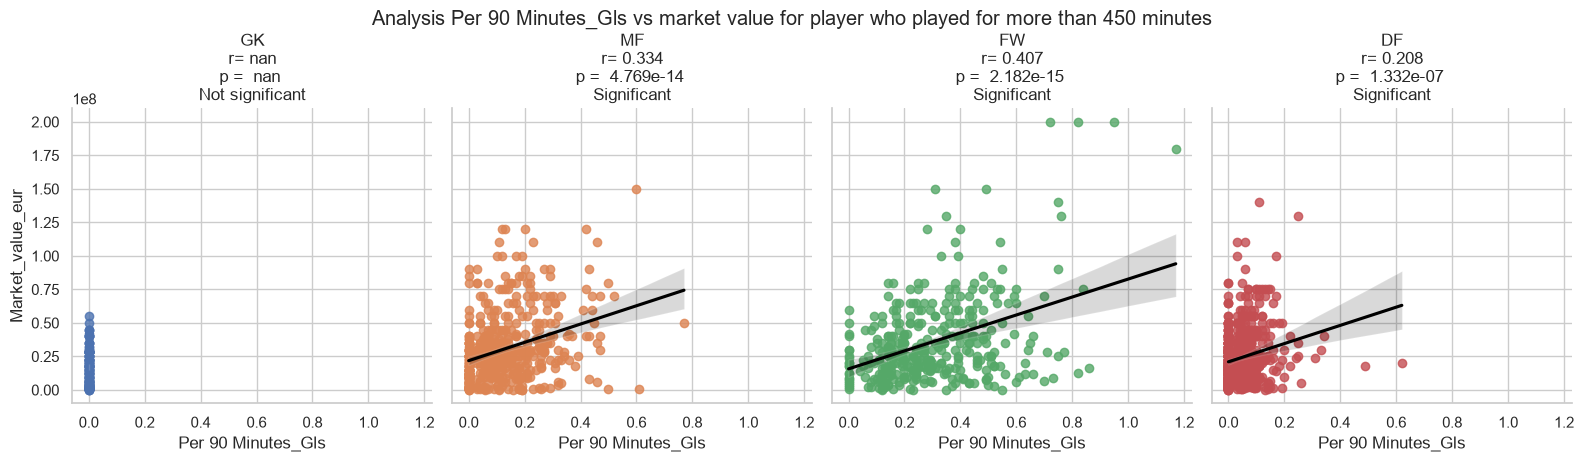

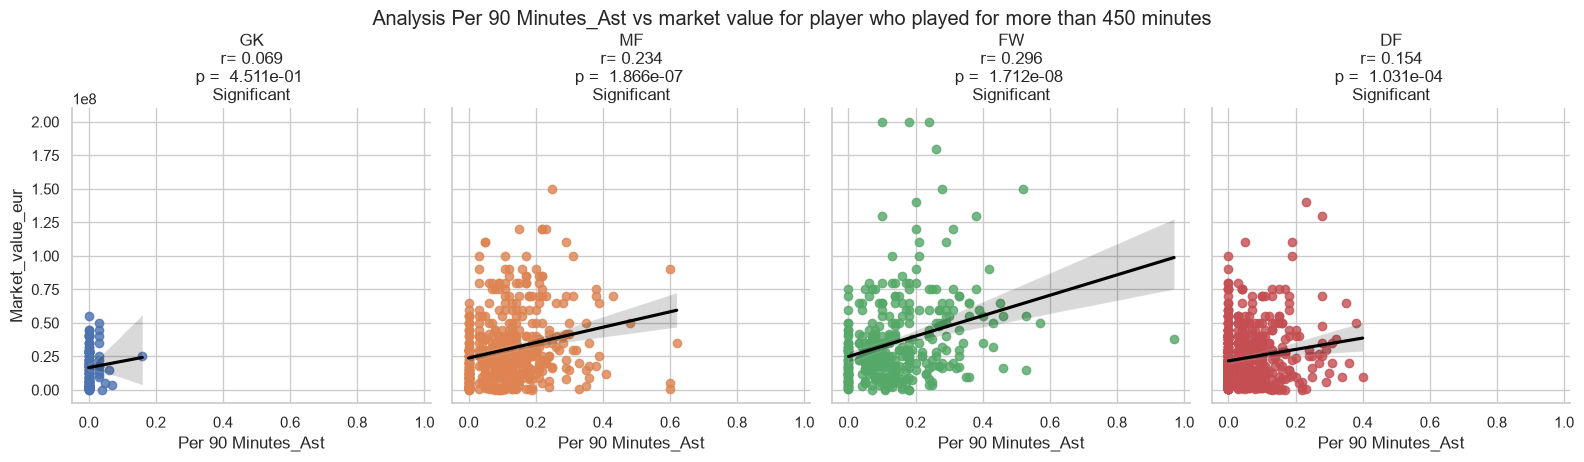

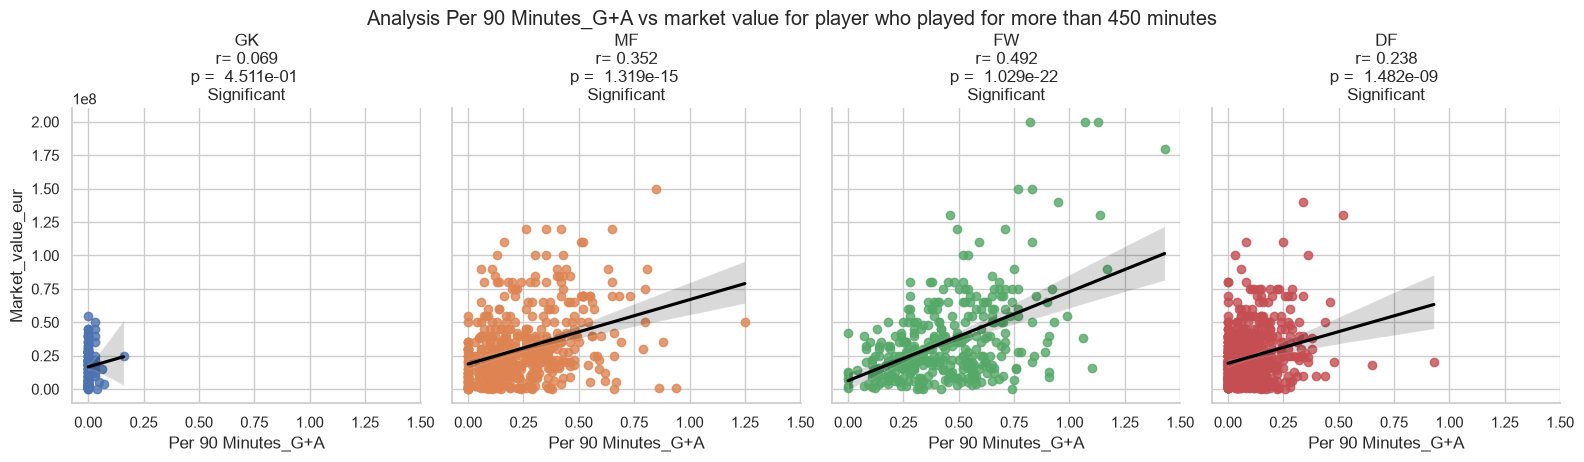

[09/09/26 20:58:57] WARNING  C:\Users\user\AppData\Local\Temp\ipykernel_30020\813089137.py:65:  ]8;id=3688592;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=3688593;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             ConstantInputWarning: An input array is constant; the correlation                     
                             coefficient is not defined.                                                           
                               r_val, p_val = stats.pearsonr(clean_slice,                                          
                             clean_slice['Market_value_eur'])                                                      
                                                                                                                   

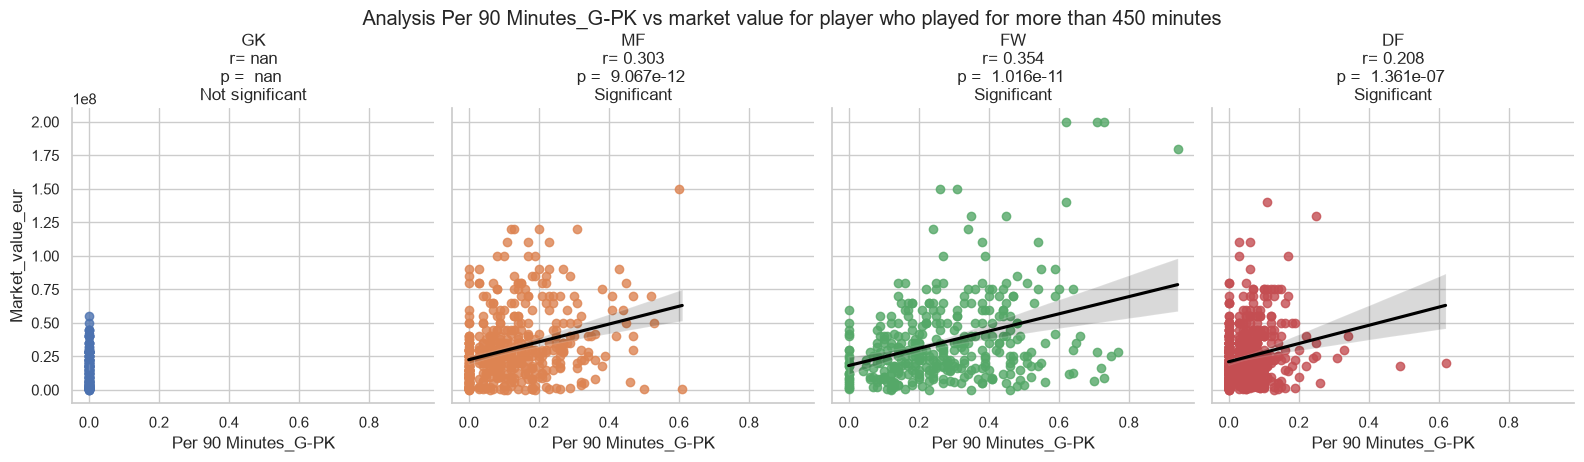

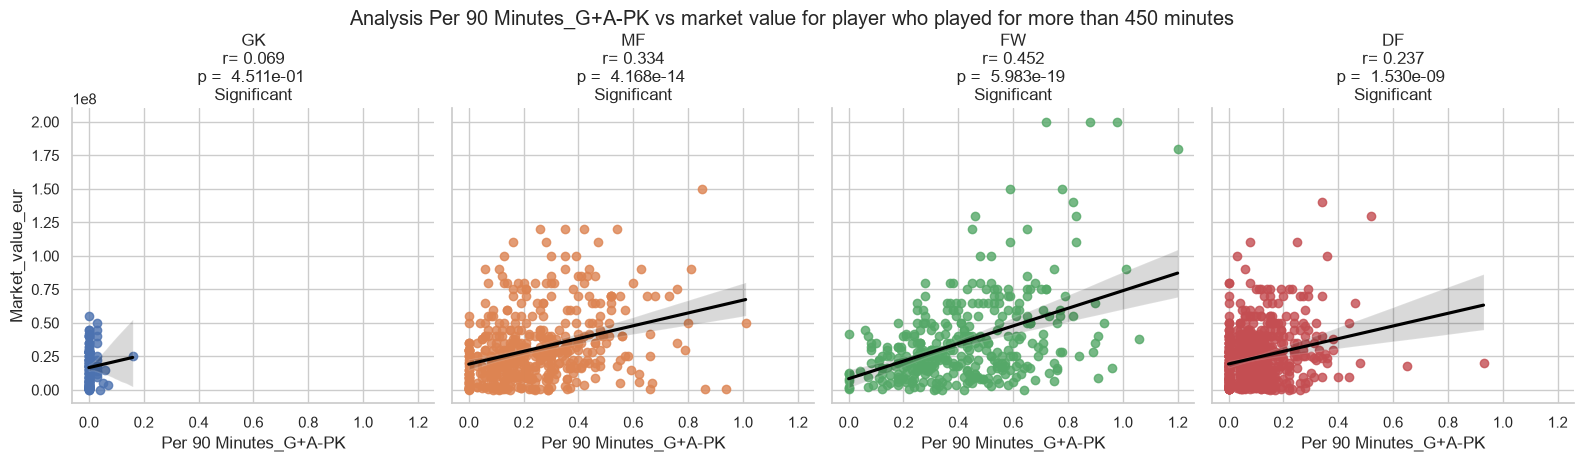

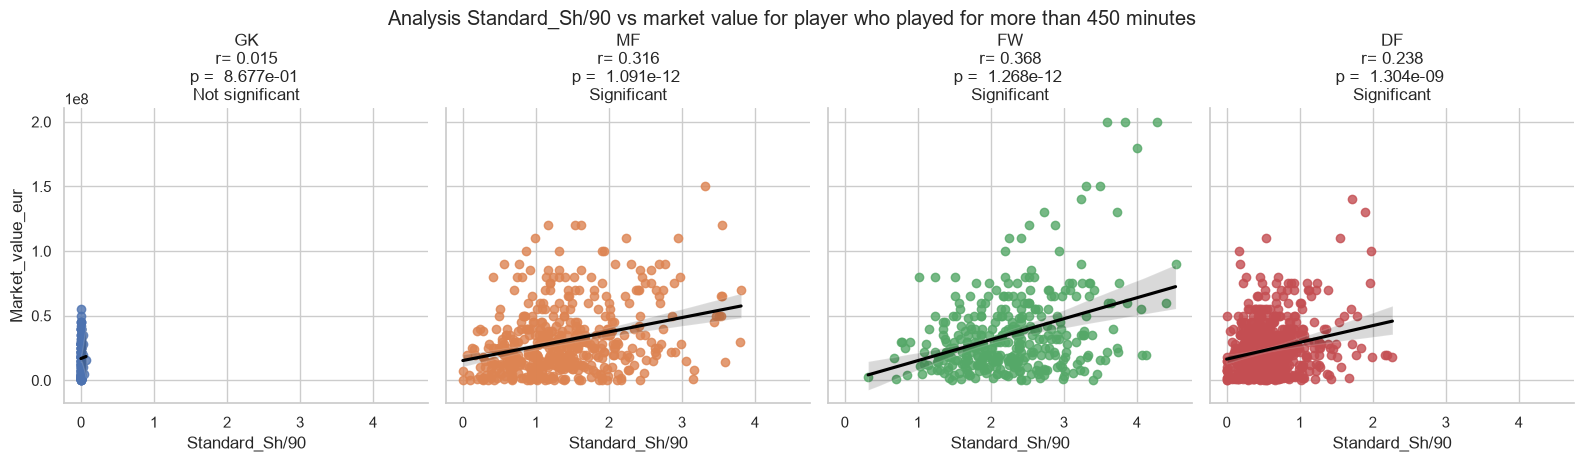

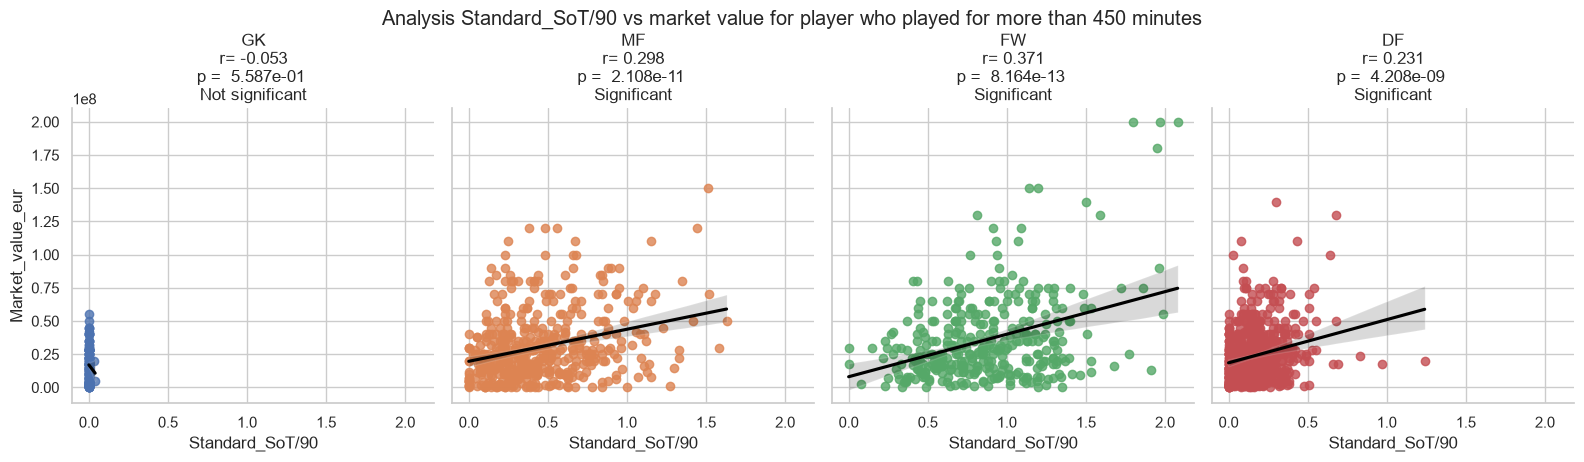

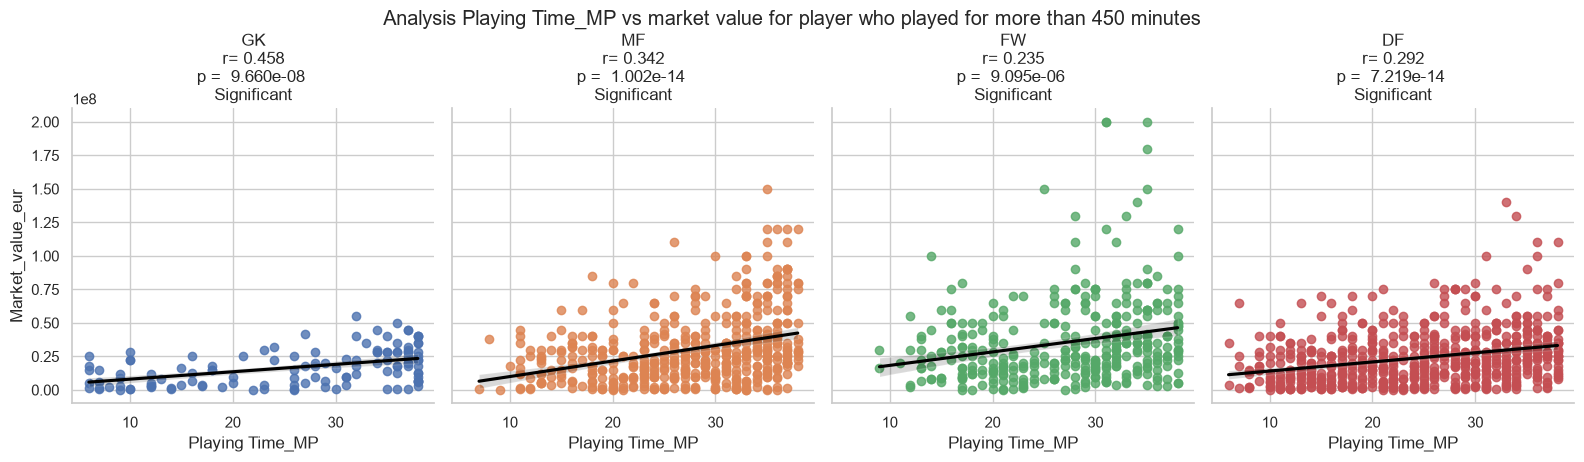

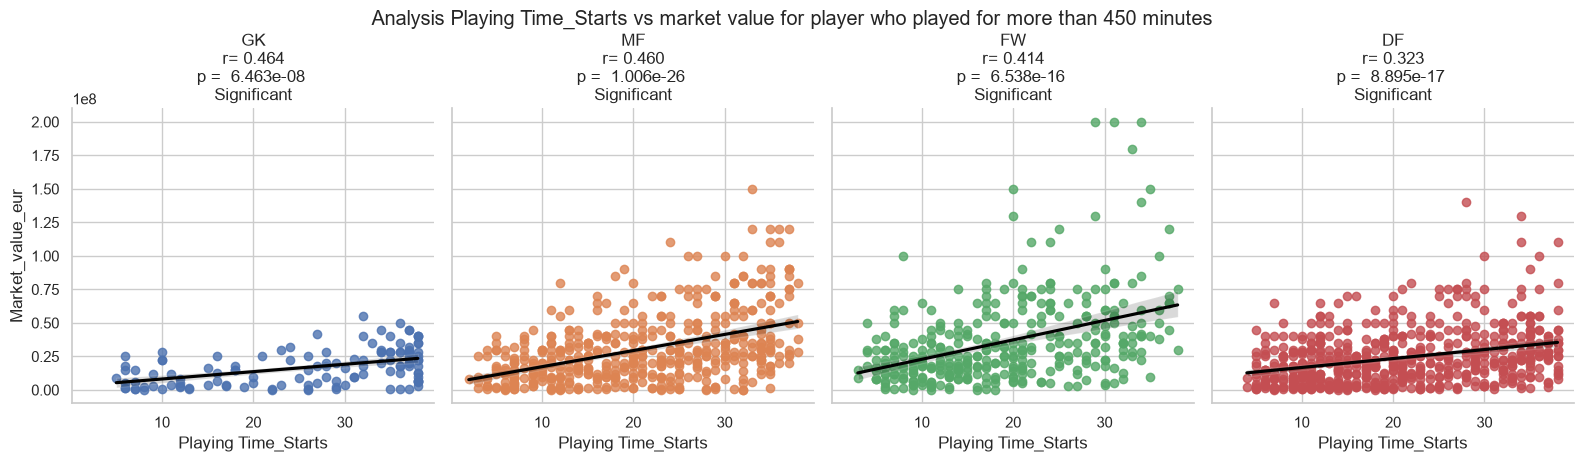

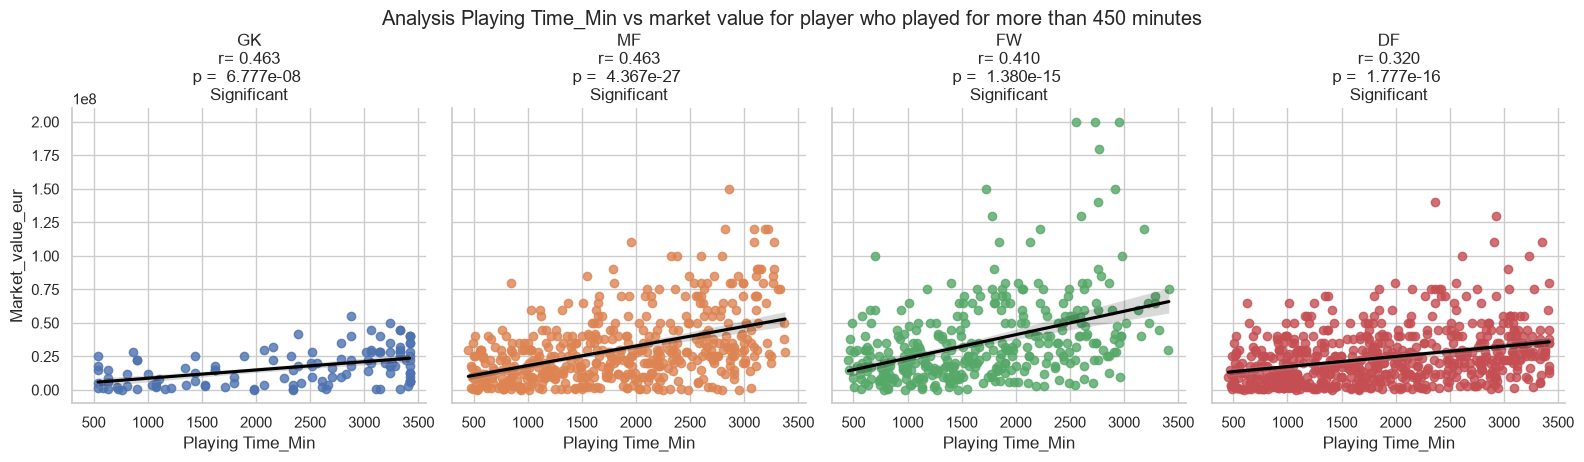

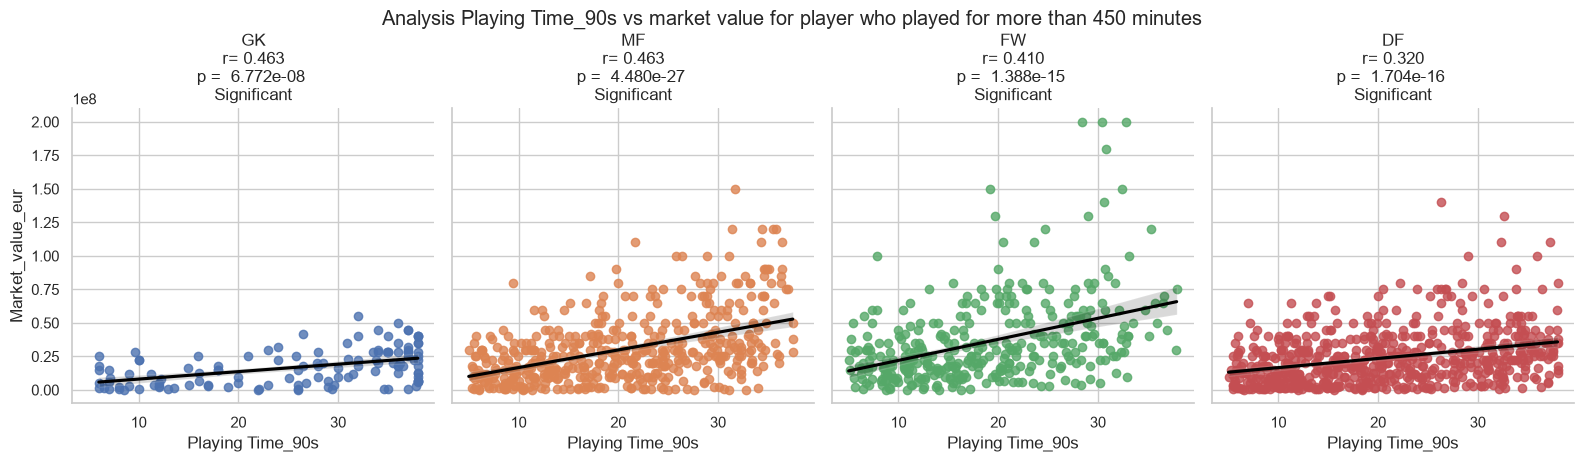

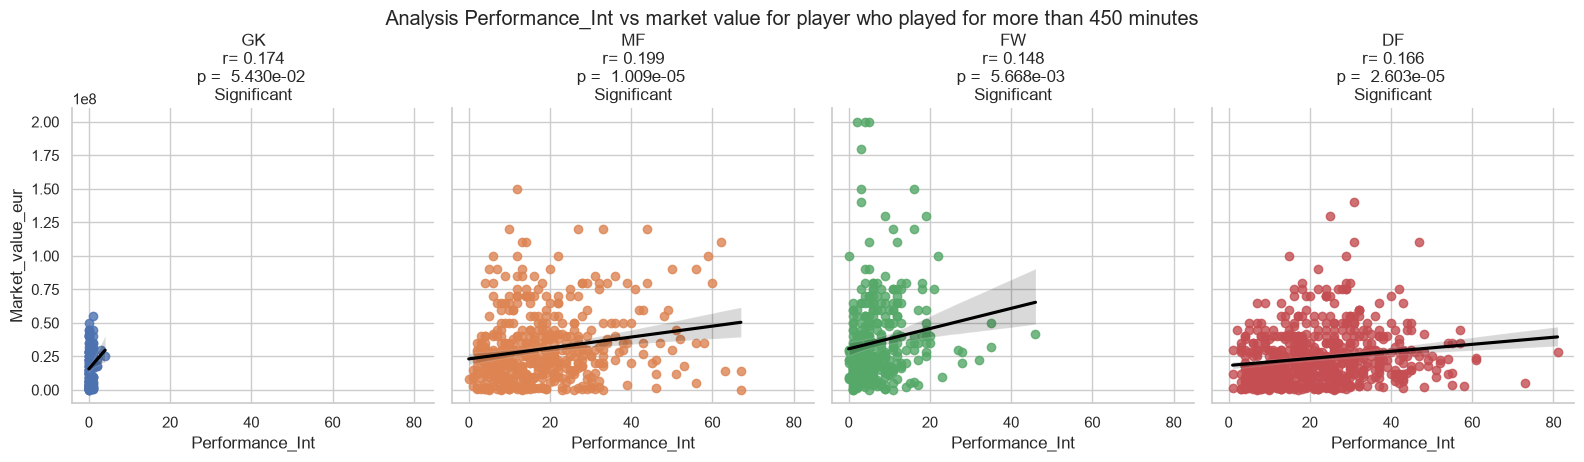

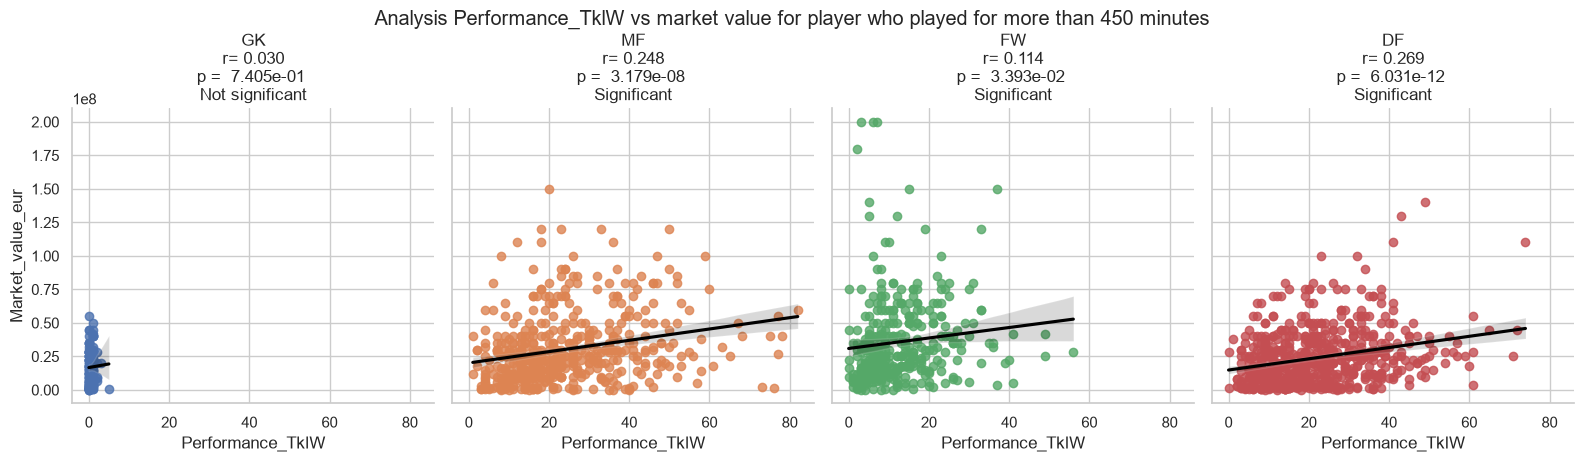

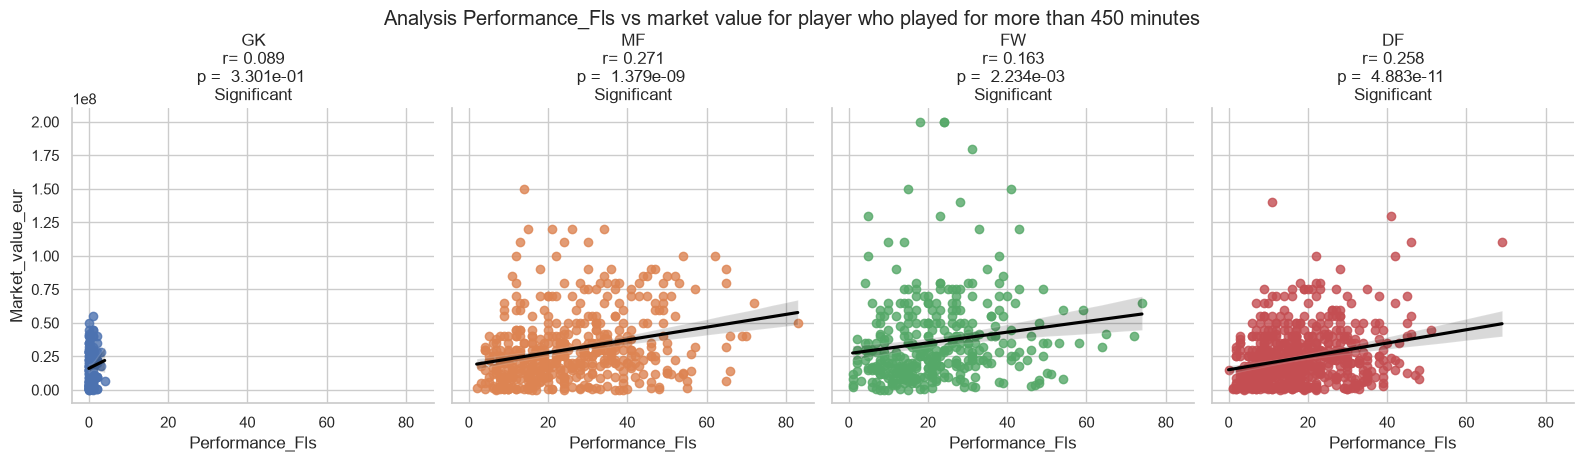

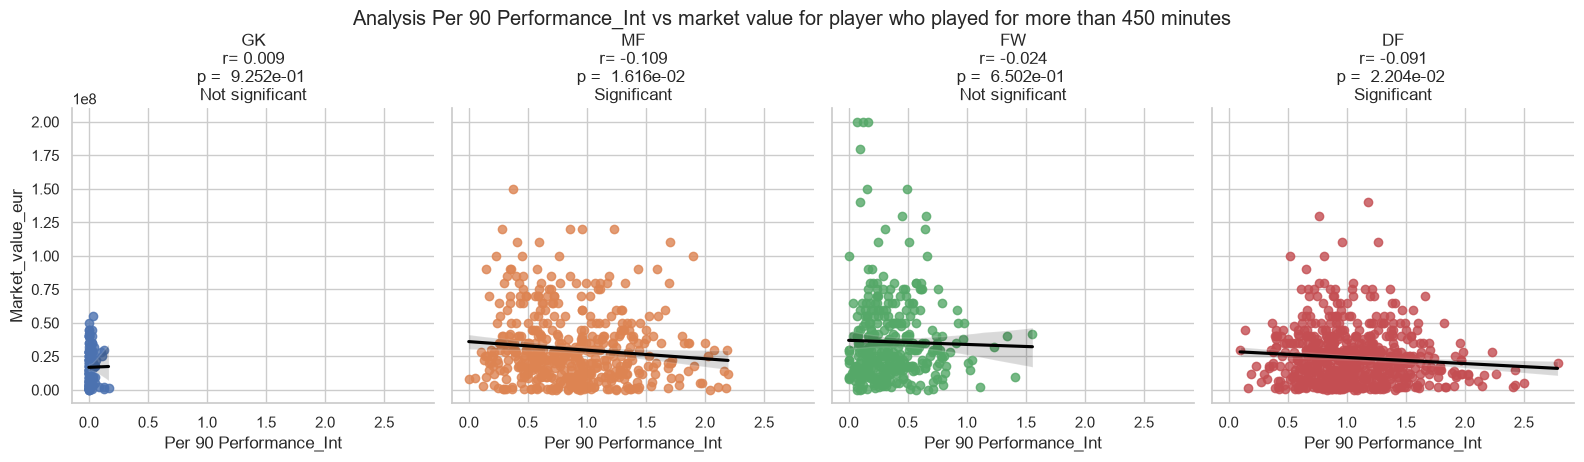

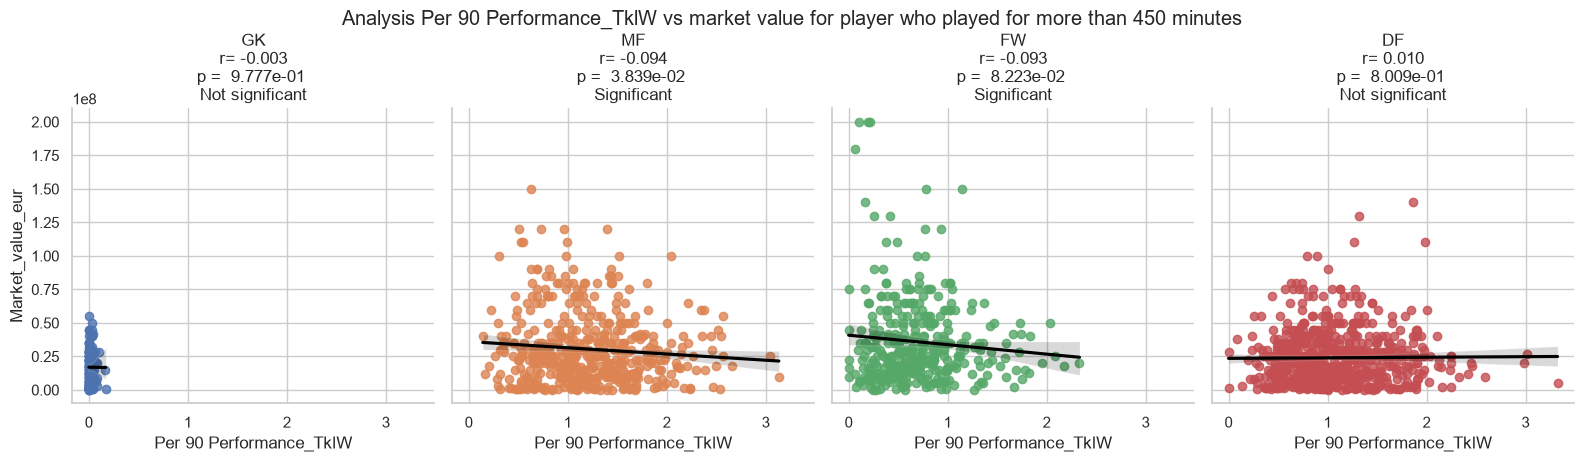

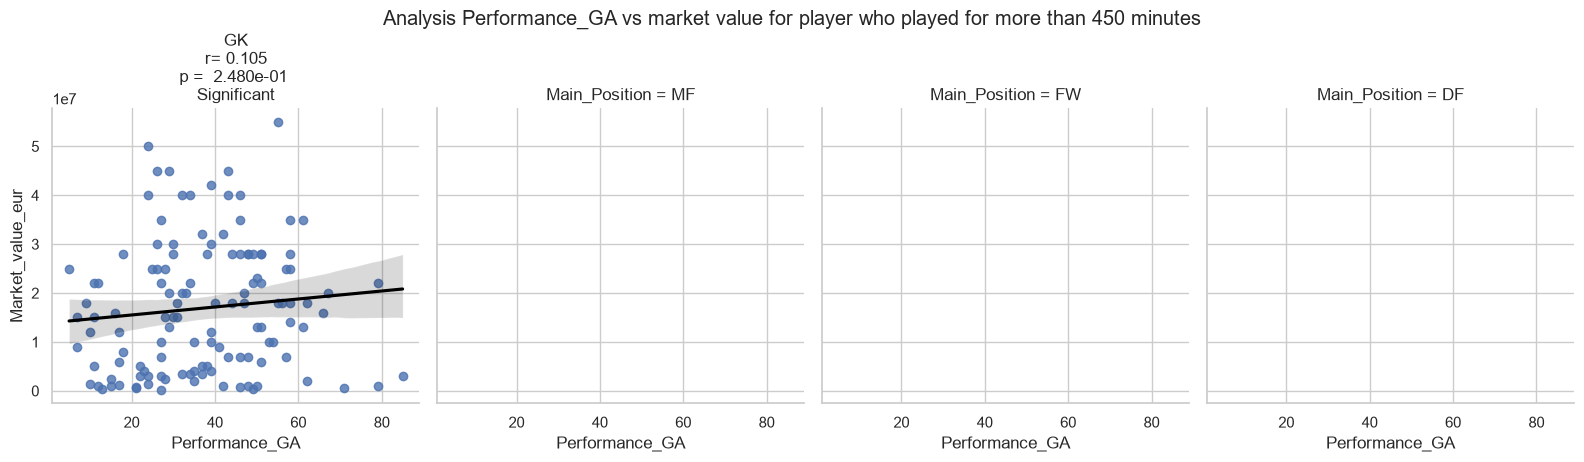

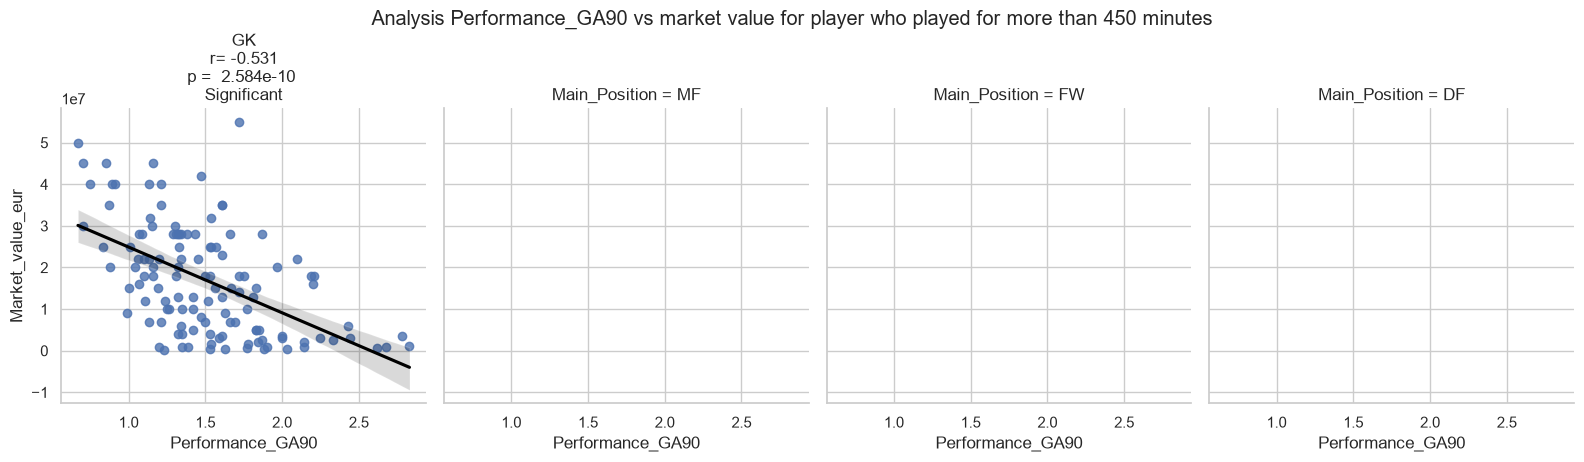

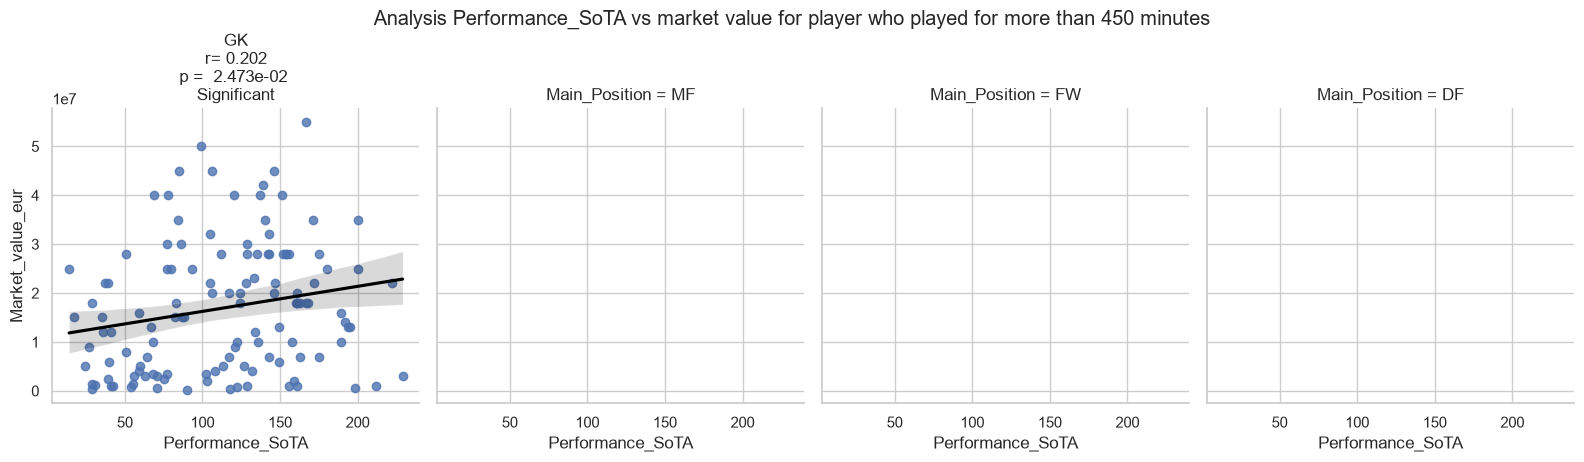

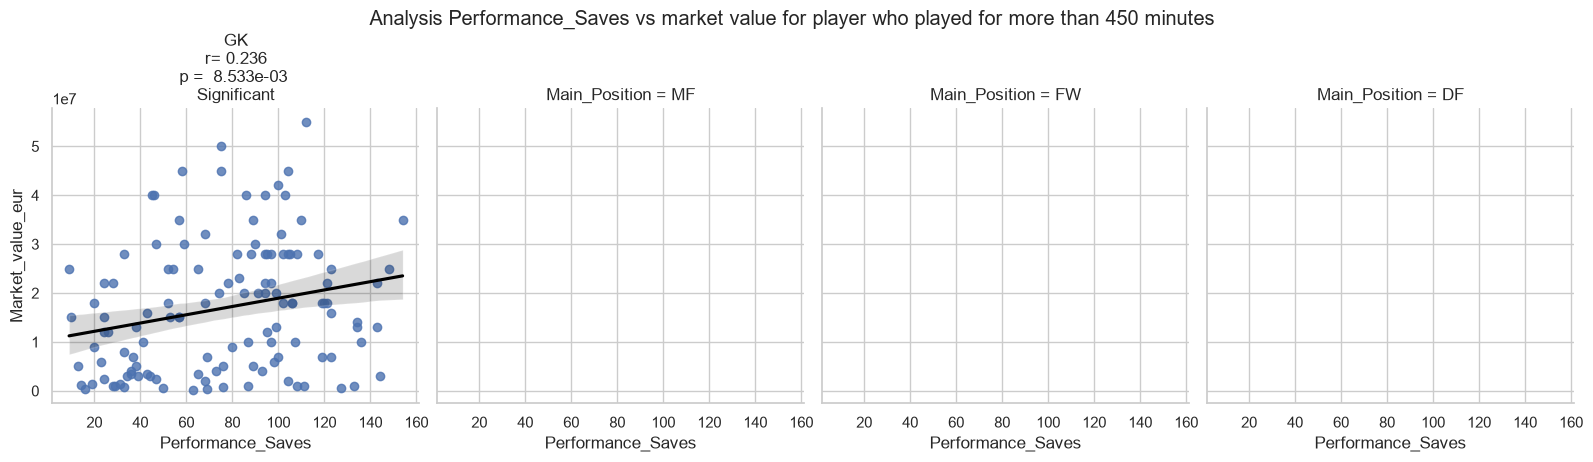

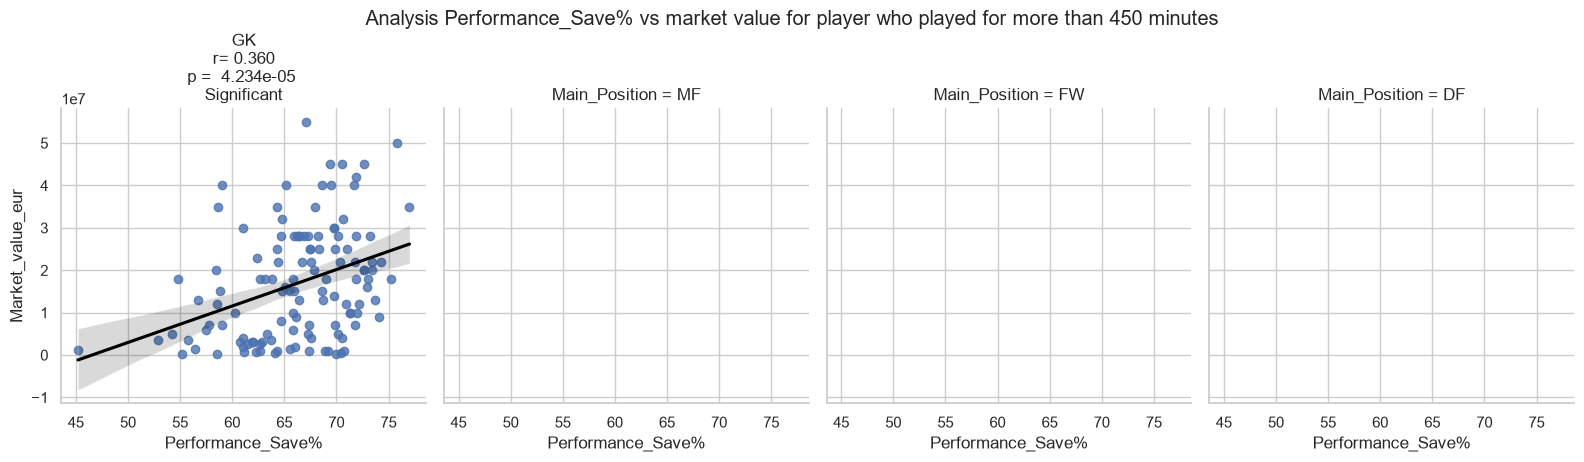

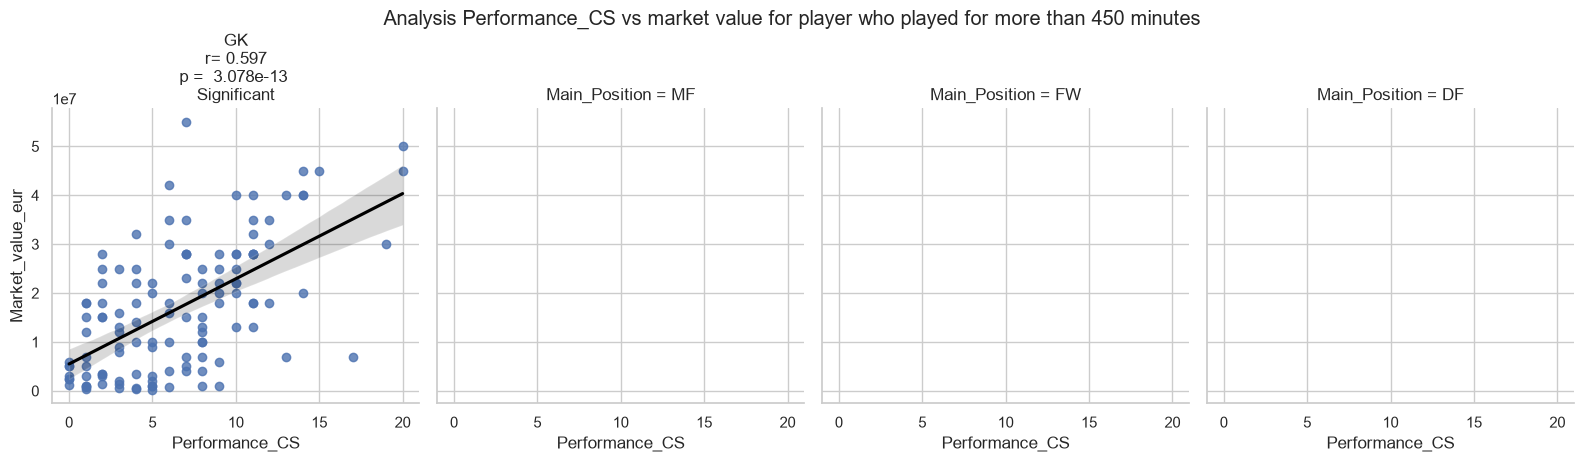

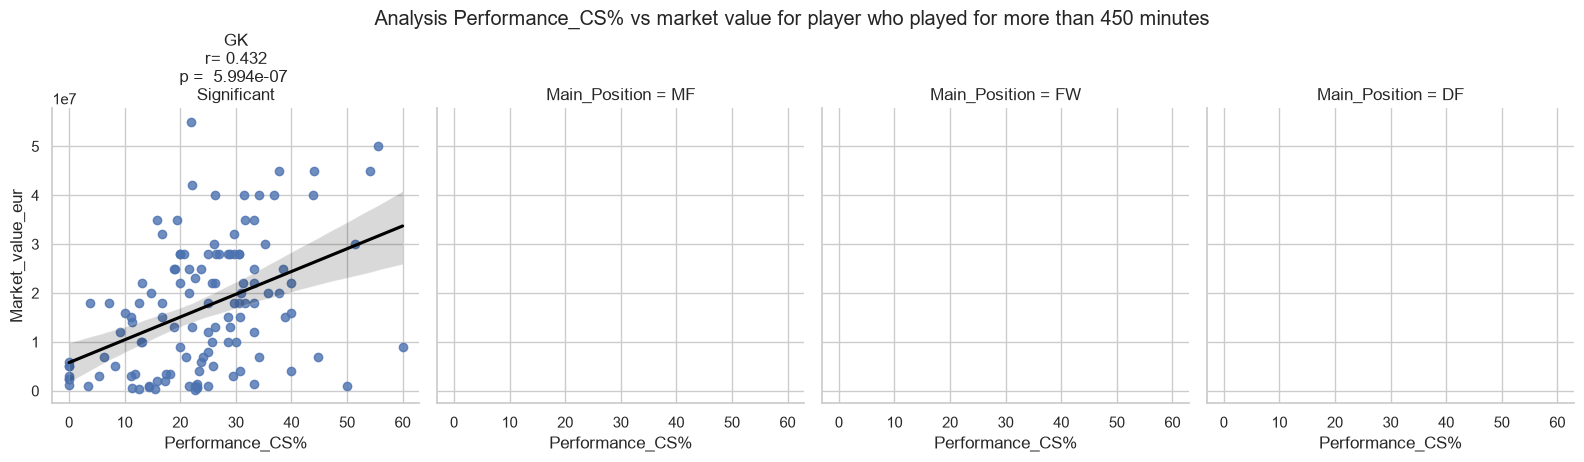

There are: 123 players in GK position
There are: 632 players in DF position
There are: 349 players in FW position
There are: 484 players in MF position
training data saved


In [43]:
#We want to do some visulization before training our model(EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
sns.set_theme(style="whitegrid")
age = ['age']
attack = ['Performance_Gls', 'Performance_Ast''Standard_Sh', 'Standard_SoT',
            'Standard_SoT%', 'Standard_G/Sh',
            'Standard_G/SoT', 'Performance_Crs' ]
attack_per_90 = ['Per 90 Minutes_Gls','Per 90 Minutes_Ast','Per 90 Minutes_G+A','Per 90 Minutes_G-PK','Per 90 Minutes_G+A-PK', 'Standard_Sh/90', 'Standard_SoT/90']

g = sns.pairplot(data = master_raw_df, y_vars = ['Market_value_eur'], x_vars= age, hue = 'pos', palette = 'tab10', height = 6)
plt.show()

g = sns.pairplot(data= master_raw_df, y_vars= ['Market_value_eur'], x_vars = attack_per_90, hue = 'pos', palette = 'tab10', height = 6)
plt.show

#the plots aboved identified a problem with position and also outliers which the case is if a player only played a game and had a huge impact on the game  the expected
# clean the df
df_filtered = master_raw_df[master_raw_df['Playing Time_Min'] > 450].copy()
#Creating per 90 stats for interception and tackles won
if 'Performance_Int' in df_filtered.columns:
    df_filtered['Per 90 Performance_Int'] = (df_filtered['Performance_Int'] / df_filtered['Playing Time_Min']) * 90
if 'Performance_TklW' in df_filtered.columns:
    df_filtered['Per 90 Performance_TklW'] = (df_filtered['Performance_TklW'] / df_filtered['Playing Time_Min']) * 90
    print('per 90 stats generated')

#clean up positions such as 'df, fw' into df
def simplify_position(pos_str):
    if not isinstance(pos_str, str):
        return 'Other'
    if 'GK' in pos_str: return 'GK'
    if 'DF' in pos_str: return 'DF'
    if 'FW' in pos_str: return 'FW'
    if 'MF' in pos_str: return 'MF'
    return 'Other'

df_filtered['Main_Position'] = df_filtered['pos'].apply(simplify_position)


#inspection
df_filtered

#plotting the cleaned up plots in specific player positions
#For displaying media age and correlation coefficient

playtime = ['Playing Time_MP','Playing Time_Starts','Playing Time_Min','Playing Time_90s']
defense =['Performance_Int', 'Performance_TklW', 'Performance_Fls', 'Per 90 Performance_Int', 'Per 90 Performance_TklW']
keeper = ['Performance_GA', 'Performance_GA90', 'Performance_SoTA','Performance_Saves', 'Performance_Save%', 'Performance_CS', 'Performance_CS%']
all_features = age + attack + attack_per_90 + playtime + defense + keeper
for f in all_features:
    if f in df_filtered.columns:
        g = sns.lmplot( data = df_filtered,x = f, y = 'Market_value_eur', col='Main_Position', hue='Main_Position', height=4, line_kws={'color': 'black'} )

        #extract subplots
        axes_dict = g.axes_dict
        for pos_name, ax in axes_dict.items():
            pos_slice = df_filtered[df_filtered['Main_Position'] == pos_name]
            #clean missing rows
            clean_slice = pos_slice[[f, 'Market_value_eur']].dropna()


            if len(clean_slice) > 5:
                r_val, p_val = stats.pearsonr(clean_slice[f], clean_slice['Market_value_eur'])
                sig_text = "Significant" if p_val < 0.5 else "Not significant"
                #Showing our new calculated statistics
                ax.set_title(f"{pos_name}\nr= {r_val:.3f}\np = {p_val: .3e} \n{sig_text}")
    g.fig.suptitle(f"Analysis {f} vs market value for player who played for more than 450 minutes", y = 1.15)
    plt.show()

        
#Checking the number of players in specific position(will be repeated if same player play through all the season)
positions = ['GK', 'DF', 'FW', 'MF']
def num_players(position):
    return (df_filtered['Main_Position'] == position).sum()
for p in positions:
    print(f"There are: {num_players(p)} players in {p} position")

#Saving final data for training model
df_filtered.to_csv("training_data.csv", index = False)
print("training data saved")





Analysis shows that for some stats such as SoT% for keepers defenders or even midfielders are close to 100 because they dont take as many shots which can heavily skew the data
Interception, tackles won per 90 compared to interception amd tackles show even weaker correaltions that can be due to the fact substitutes with less game time can have more impact on intercepting the ball
Possession style of play can have an impact on tackles won or interception if a team keeps possession, defenders may make fewer tackles compare to counter attacking style of play

In [106]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor



#Initially I thought of removing teams completely but the model may not understand superstars values so club tier list is created
#Creating club tiers based on historical market spending and league position(Target encoding)
tier_1 = ['Manchester City', 'Arsenal', 'Liverpool', 'Chelsea', 'Manchester Utd', 'Tottenham']
tier_2 = ['Aston Villa', 'Newcastle', 'Brighton', 'Everton', 'Crystal Palace']

def assign_club_tier(team):
    if team in tier_1:
        return 3
    elif team in tier_2:
        return 2
    else:
        return 1

df_filtered['Club_tier'] = df_filtered['team'].apply(assign_club_tier)
#Dropping columns which will not be used in the model
dropped_col = ['league', 'player', 'team', 'nation', 'pos', 'born']
df_ml = df_filtered.drop(columns = [col for col in dropped_col if col in df_filtered.columns])

#one hot encoding converting position text into numerical form
df_ml = pd.get_dummies(df_ml, columns= ['Main_Position'], drop_first= True)
#inspect
df_ml
#convert boolean into 1 and 0
for col in df_ml.columns:
    if df_ml[col].dtype == 'bool':
        df_ml[col] = df_ml[col].astype(int)

#change NaN to 0
df_ml = df_ml.fillna(0)

#train/test split
train_set = df_ml[df_ml['season'] != '2025-26'].copy()
test_set = df_ml[df_ml['season'] == '2025-26'].copy()
#HEaders for analysis
test_meta = df_filtered[df_filtered['season'] == '2025-26'][['player', 'team', 'season', 'Market_value_eur']].copy()

# split data into X & y
X_train = train_set.drop(columns=['season', 'Market_value_eur'])
y_train = train_set['Market_value_eur']

X_test = test_set.drop(columns=['season', 'Market_value_eur'])
y_test = test_set['Market_value_eur']
print( f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")

#Initialize XGBoost regressor
xgb_model = XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 42, depth = 3)

#Train our model
xgb_model.fit(X_train, y_train)

#Predictions
y_pred = xgb_model.predict(X_test)

#Evaluate the model

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2_train =  xgb_model.score(X_train, y_train)
r2_test = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE:", {mae})
print(f"R^2 Score on training: {r2_train}")
print(f"R^2 Score on test: {r2_test}")
#decode my mse
rmse = np.sqrt(mse)
print("Average price prediction deviation:", rmse)

Training rows: 1203, Test rows: 385


                    WARNING  c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-pac ]8;id=3688658;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py\_py_warnings.py]8;;\:]8;id=3688659;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\_py_warnings.py#230\230]8;;\
                             kages\xgboost\training.py:200: UserWarning: [23:06:29] WARNING:                       
                             C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794:                           
                             Parameters: { "depth" } are not used.                                                 
                                                                                                                   
                               bst.update(dtrain, iteration=i, fobj=obj)                                           
                                                                                                                   

MSE: 215736089837568.0
MAE: {9668254.0}
R^2 Score on training: 0.9651147723197937
R^2 Score on test: 0.6438363790512085
Average price prediction deviation: 14687957.306500044


In [107]:
#Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
param_dist = {'n_estimators': [50,100,150, 200],
              'learning_rate': [0.01, 0.02, 0.04, 0.06, 0.1, 0.2],
              'max_depth': [2,3,4],
              'subsample': [0.7, 0.8, 0.9,1],
              'colsample_bytree': [0.7, 0.8, 0.9,1],
              'gamma': [0, 0.1, 0.2]}
xgb_base = XGBRegressor(random_state = 42)
#Initialise RandomizedSearchCV
random_search = RandomizedSearchCV(estimator= xgb_base, param_distributions= param_dist, 
                                   n_iter = 20,
                                   cv = 5,
                                   verbose = 1,
                                   n_jobs= -1,)
# run RandomizedSearchCV
random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Best parameters:", best_params)

#Evaulate the best model
best_model = random_search.best_estimator_
tuned_train = best_model.predict(X_train)
tuned_y_pred = best_model.predict(X_test)

#Calc new metrics
mse_tuned = mean_squared_error(y_test, tuned_y_pred)
mae_tuned = mean_absolute_error(y_test, tuned_y_pred)
r2_train_tuned = r2_score(tuned_train, y_train)
r2_test_tuned = r2_score(y_test, tuned_y_pred)

print(f"Tuned MSE: {mse_tuned}")
print(f"Tuned MAE: {mae_tuned}")
print(f"R^2 Score on training tuned: {r2_train_tuned}")
print(f"R^2 Score on test: {r2_test_tuned}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1}
Tuned MSE: 202095995125760.0
Tuned MAE: 9548827.0
R^2 Score on training tuned: 0.864401638507843
R^2 Score on test: 0.6663551330566406


In [ ]:
#Plot for actual vs predicted

In [ ]:
#Test
import pandas as pd
import soccerdata as sd
from soccerdata import FBref
fbref = sd.FBref('ENG-Premier League', 2526)
player_season_stats = fbref.read_player_season_stats(stat_type="standard")
player_season_stats

[09/07/26 12:03:17] INFO     Saving cached data to C:\Users\user\soccerdata\data\FBref               ]8;id=12971111;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=12971112;file://c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\soccerdata\_common.py#250\250]8;;\

nation    pos age  born  \
                                                                               
league             season team    player                                       
ENG-Premier League 2526   Arsenal Ben White             ENG     DF  27  1997   
                                  Bukayo Saka           ENG  FW,MF  23  2001   
                                  Christian Nørgaard    DEN     MF  31  1994   
                                  Cristhian Mosquera    ESP     DF  21  2004   
                                  David Raya            ESP     GK  29  1995   
...                                                     ...    ...  ..   ...   
                          Wolves  Tawanda Chirewa       ZIM     MF  21  2003   
                                  Tolu Arokodare        NGA     FW  24  2000   
                                  Tom Edozie            ENG     MF  19  2006   
                                  Toti Gomes            POR     DF  26  1999   
                                  Yerson Mosquera       COL     DF  24  2001   

                                                     Playing Time         \
                                                               MP Starts   
league             season team    player                                   
ENG-Premier League 2526   Arsenal Ben White                    12      9   
                                  Bukayo Saka                  31     25   
                                  Christian Nørgaard            7      1   
                                  Cristhian Mosquera           20      9   
                                  David Raya                   37     37   
...                                                           ...    ...   
                          Wolves  Tawanda Chirewa               2      0   
                                  Tolu Arokodare               33     13   
                                  Tom Edozie                    3      0   
                                  Toti Gomes                   19     17   
                                  Yerson Mosquera              27     24   

                                                                 Performance  \
                                                       Min   90s         Gls   
league             season team    player                                       
ENG-Premier League 2526   Arsenal Ben White            702   7.8           0   
                                  Bukayo Saka         2222  24.7           7   
                                  Christian Nørgaard   106   1.2           0   
                                  Cristhian Mosquera   994  11.0           0   
                                  David Raya          3330  37.0           0   
...                                                    ...   ...         ...   
                          Wolves  Tawanda Chirewa       27   0.3           0   
                                  Tolu Arokodare      1419  15.8           3   
                                  Tom Edozie            14   0.2           1   
                                  Toti Gomes          1424  15.8           0   
                                  Yerson Mosquera     2136  23.7           0   

                                                          ...                \
                                                     Ast  ... G-PK PK PKatt   
league             season team    player                  ...                 
ENG-Premier League 2526   Arsenal Ben White            1  ...    0  0     0   
                                  Bukayo Saka          5  ...    6  1     1   
                                  Christian Nørgaard   0  ...    0  0     0   
                                  Cristhian Mosquera   0  ...    0  0     0   
                                  David Raya           0  ...    0  0     0   
...                                                   ..  ...  ... ..   ...   
                          Wolves  T